# ESoC 2026 — CLAAS Challenge: MF4 Data Exploration

Five runs of harvester sensor data. Each run = one continuous recording session.  
Each run contains one or more **episodes** (header On → Off periods).  
Goal: detect stones from audio (Sensor1) before the metal detector (VoltageSignal) fires.

In [1]:
from asammdf import MDF
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from pathlib import Path

DATA_DIR = Path("data")
MF4_FILES = sorted(DATA_DIR.glob("*.mf4"))
print("Files found:")
for f in MF4_FILES:
    print(f"  {f.name}")

Files found:
  Messung_2025-05-09_08-59-34.mf4
  Messung_2025-05-14_16-02-23.mf4
  Messung_2025-05-20_16-30-26.mf4
  Messung_2025-10-01_09-42-16.mf4
  Messung_2025-10-01_17-18-12.mf4


## 1. Channel overview — what's in each file

In [2]:
def load_run(path):
    """Load an MF4 file and return a dict of {channel_name: Signal}."""
    mf = MDF(path)
    channels = {}
    for name in ["Sensor1", "VehicleSpeed", "CutLength", "VoltageSignal", "Status"]:
        try:
            channels[name] = mf.get(name)
        except Exception as e:
            print(f"  Warning: could not load {name}: {e}")
    return channels

# Print a summary table for all runs
rows = []
for f in MF4_FILES:
    ch = load_run(f)
    audio = ch["Sensor1"]
    volt = ch["VoltageSignal"]
    status = ch["Status"]
    speed = ch["VehicleSpeed"]
    
    status_str = status.samples.astype(str)
    transitions = np.where(status_str[:-1] != status_str[1:])[0]
    n_episodes = int(np.sum(
        (status_str[transitions] == 'Off') & (status_str[transitions + 1] == 'On')
    ))
    
    rows.append({
        "Run": f.stem,
        "Duration (s)": f"{audio.timestamps[-1]:.1f}",
        "Audio samples": f"{len(audio.samples):,}",
        "Audio Hz": f"{len(audio.samples)/audio.timestamps[-1]:.0f}",
        "Episodes": n_episodes,
        "Volt median": f"{np.median(volt.samples):.1f}",
        "Volt max": f"{volt.samples.max():.0f}",
        "Speed max (km/h)": f"{speed.samples.max():.1f}",
        "CutLength": str(np.unique(ch["CutLength"].samples).tolist()),
    })

df_summary = pd.DataFrame(rows)
df_summary

,Run,Duration (s),Audio samples,Audio Hz,Episodes,Volt median,Volt max,Speed max (km/h),CutLength
0,Messung_2025-05-09_08-59-34,245.5,"10,804,500",44012,2,97.0,513,9.5,[9.0]
1,Messung_2025-05-14_16-02-23,150.6,"6,636,544",44074,1,36.0,10668,4.4,[9.0]
2,Messung_2025-05-20_16-30-26,340.5,"14,994,000",44036,4,35.0,10220,6.5,[9.0]
3,Messung_2025-10-01_09-42-16,600.0,"26,455,561",44093,8,49.0,10927,16.5,[15.0]
4,Messung_2025-10-01_17-18-12,471.4,"20,786,176",44095,3,132.0,9611,22.1,"[15.0, 18.0]"


## 2. Episode structure — when is the header On vs Off?

Each Off→On transition starts an episode. The header running = crop (and potentially stones) being ingested.

In [3]:
def get_episodes(status_channel):
    """Return list of (start_time, end_time) for each On period."""
    s = status_channel.samples.astype(str)
    t = status_channel.timestamps
    changes = np.where(s[:-1] != s[1:])[0]
    episodes = []
    for i in changes:
        if s[i] == 'Off' and s[i+1] == 'On':
            start = t[i+1]
            # find next Off after this On
            future_off = [t[j+1] for j in changes if j > i and s[j] == 'On' and s[j+1] == 'Off']
            end = future_off[0] if future_off else t[-1]
            episodes.append((start, end))
    return episodes

for f in MF4_FILES:
    ch = load_run(f)
    episodes = get_episodes(ch["Status"])
    print(f"\n{f.name}")
    for i, (s, e) in enumerate(episodes):
        print(f"  Episode {i+1}: {s:.2f}s → {e:.2f}s  (duration: {e-s:.2f}s)")


Messung_2025-05-09_08-59-34.mf4
  Episode 1: 53.09s → 125.02s  (duration: 71.94s)
  Episode 2: 191.88s → 249.51s  (duration: 57.64s)

Messung_2025-05-14_16-02-23.mf4
  Episode 1: 93.53s → 120.65s  (duration: 27.12s)

Messung_2025-05-20_16-30-26.mf4
  Episode 1: 81.92s → 107.32s  (duration: 25.40s)
  Episode 2: 146.07s → 158.95s  (duration: 12.88s)
  Episode 3: 220.41s → 239.29s  (duration: 18.88s)
  Episode 4: 300.50s → 323.44s  (duration: 22.94s)

Messung_2025-10-01_09-42-16.mf4
  Episode 1: 14.66s → 26.46s  (duration: 11.80s)
  Episode 2: 36.76s → 63.00s  (duration: 26.24s)
  Episode 3: 135.36s → 164.61s  (duration: 29.26s)
  Episode 4: 232.85s → 280.25s  (duration: 47.40s)
  Episode 5: 295.75s → 324.77s  (duration: 29.02s)
  Episode 6: 413.74s → 437.12s  (duration: 23.38s)
  Episode 7: 500.74s → 530.13s  (duration: 29.40s)
  Episode 8: 552.83s → 578.85s  (duration: 26.02s)

Messung_2025-10-01_17-18-12.mf4
  Episode 1: 4.20s → 323.40s  (duration: 319.20s)
  Episode 2: 394.78s → 407.

## 3. Stone event detection — reading VoltageSignal spikes

The metal detector fires a large spike when it detects metal. We use an adaptive threshold
(baseline + N×std) to find spike onsets within each episode.

In [4]:
def find_stone_events(volt_channel, episodes, spike_multiplier=5.0):
    """
    Find voltage spike onsets (stone detection events) within each episode.
    Returns list of spike times per episode.
    """
    v = volt_channel.samples
    t = volt_channel.timestamps
    results = []
    
    for ep_start, ep_end in episodes:
        mask = (t >= ep_start) & (t <= ep_end)
        v_ep = v[mask]
        t_ep = t[mask]
        if len(v_ep) == 0:
            results.append([])
            continue
        
        # Estimate baseline from first 10% of episode (before any stone)
        n_baseline = max(10, len(v_ep) // 10)
        baseline = np.median(v_ep[:n_baseline])
        noise = np.std(v_ep[:n_baseline])
        threshold = baseline + spike_multiplier * max(noise, 1.0)
        
        spike_mask = v_ep > threshold
        edges = np.diff(spike_mask.astype(int))
        spike_starts = t_ep[np.where(edges == 1)[0] + 1]
        results.append(spike_starts.tolist())
    
    return results

for f in MF4_FILES:
    ch = load_run(f)
    episodes = get_episodes(ch["Status"])
    stone_events = find_stone_events(ch["VoltageSignal"], episodes)
    print(f"\n{f.name}")
    for i, (ep, spikes) in enumerate(zip(episodes, stone_events)):
        ep_duration = ep[1] - ep[0]
        if spikes:
            first_spike = spikes[0] - ep[0]
            print(f"  Episode {i+1} ({ep_duration:.1f}s): STONE DETECTED at +{first_spike:.3f}s into episode ({len(spikes)} spike edges)")
        else:
            print(f"  Episode {i+1} ({ep_duration:.1f}s): no stone detected")


Messung_2025-05-09_08-59-34.mf4
  Episode 1 (71.9s): STONE DETECTED at +25.424s into episode (33 spike edges)
  Episode 2 (57.6s): STONE DETECTED at +13.944s into episode (12 spike edges)

Messung_2025-05-14_16-02-23.mf4
  Episode 1 (27.1s): STONE DETECTED at +6.329s into episode (39 spike edges)

Messung_2025-05-20_16-30-26.mf4
  Episode 1 (25.4s): STONE DETECTED at +10.776s into episode (7 spike edges)
  Episode 2 (12.9s): STONE DETECTED at +1.863s into episode (72 spike edges)
  Episode 3 (18.9s): STONE DETECTED at +3.763s into episode (13 spike edges)
  Episode 4 (22.9s): STONE DETECTED at +8.876s into episode (6 spike edges)

Messung_2025-10-01_09-42-16.mf4
  Episode 1 (11.8s): STONE DETECTED at +2.493s into episode (25 spike edges)
  Episode 2 (26.2s): STONE DETECTED at +3.511s into episode (12 spike edges)
  Episode 3 (29.3s): STONE DETECTED at +8.366s into episode (9 spike edges)
  Episode 4 (47.4s): STONE DETECTED at +16.662s into episode (2 spike edges)
  Episode 5 (29.0s): 

## 4. Full run overview plot — all 5 channels together

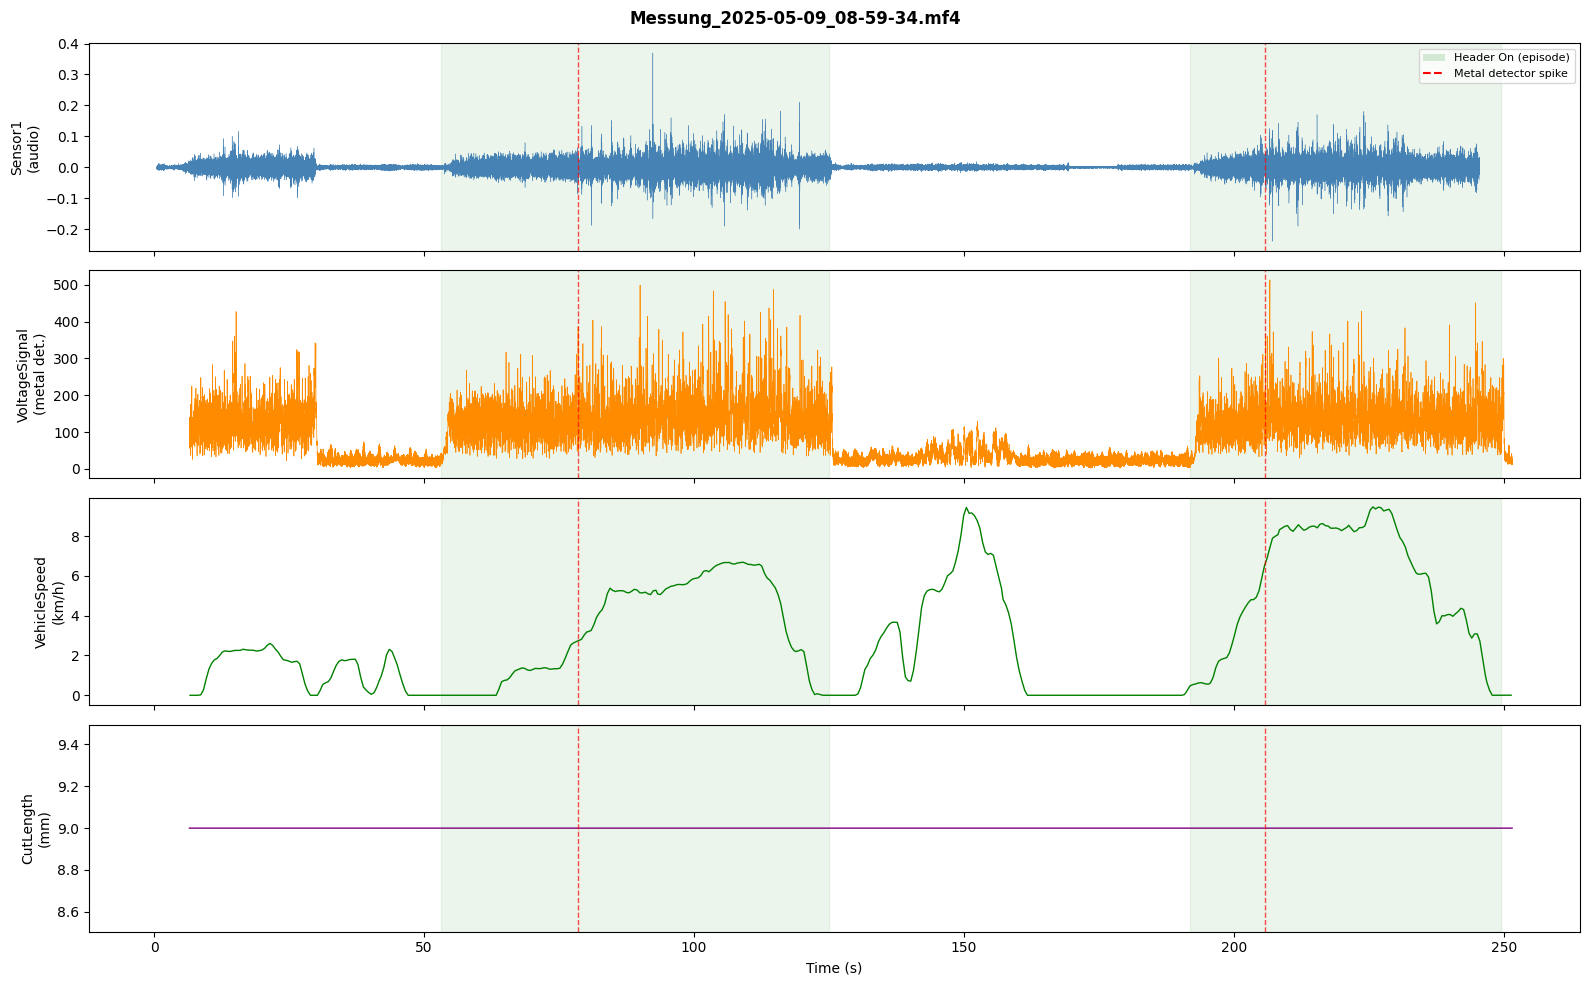

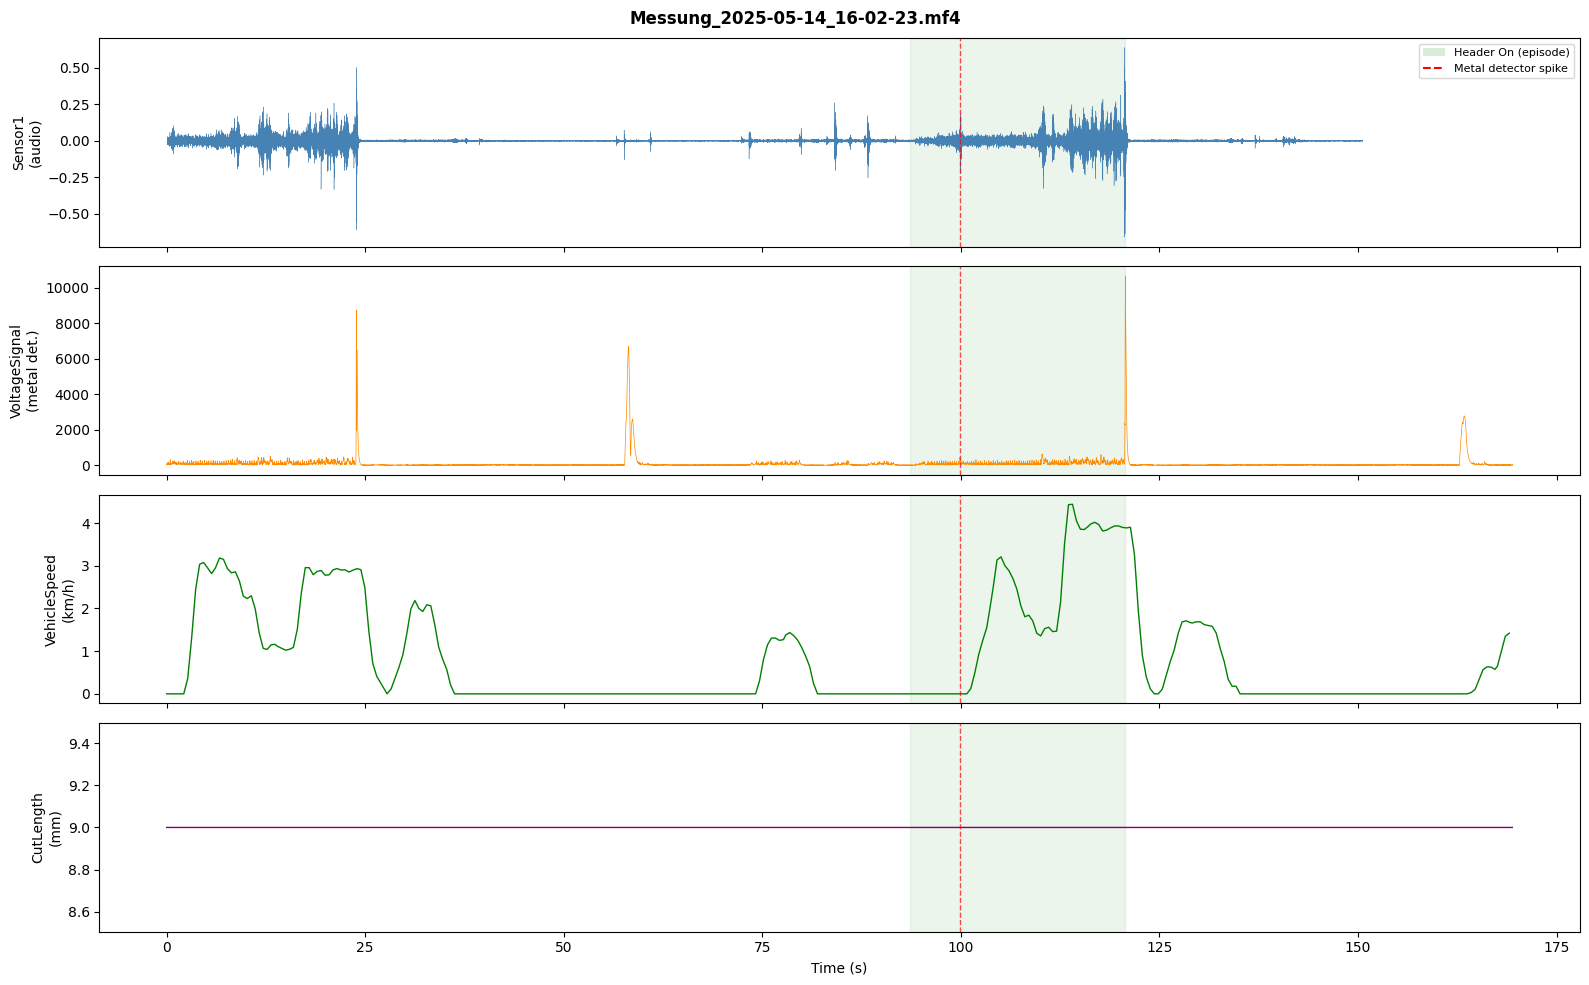

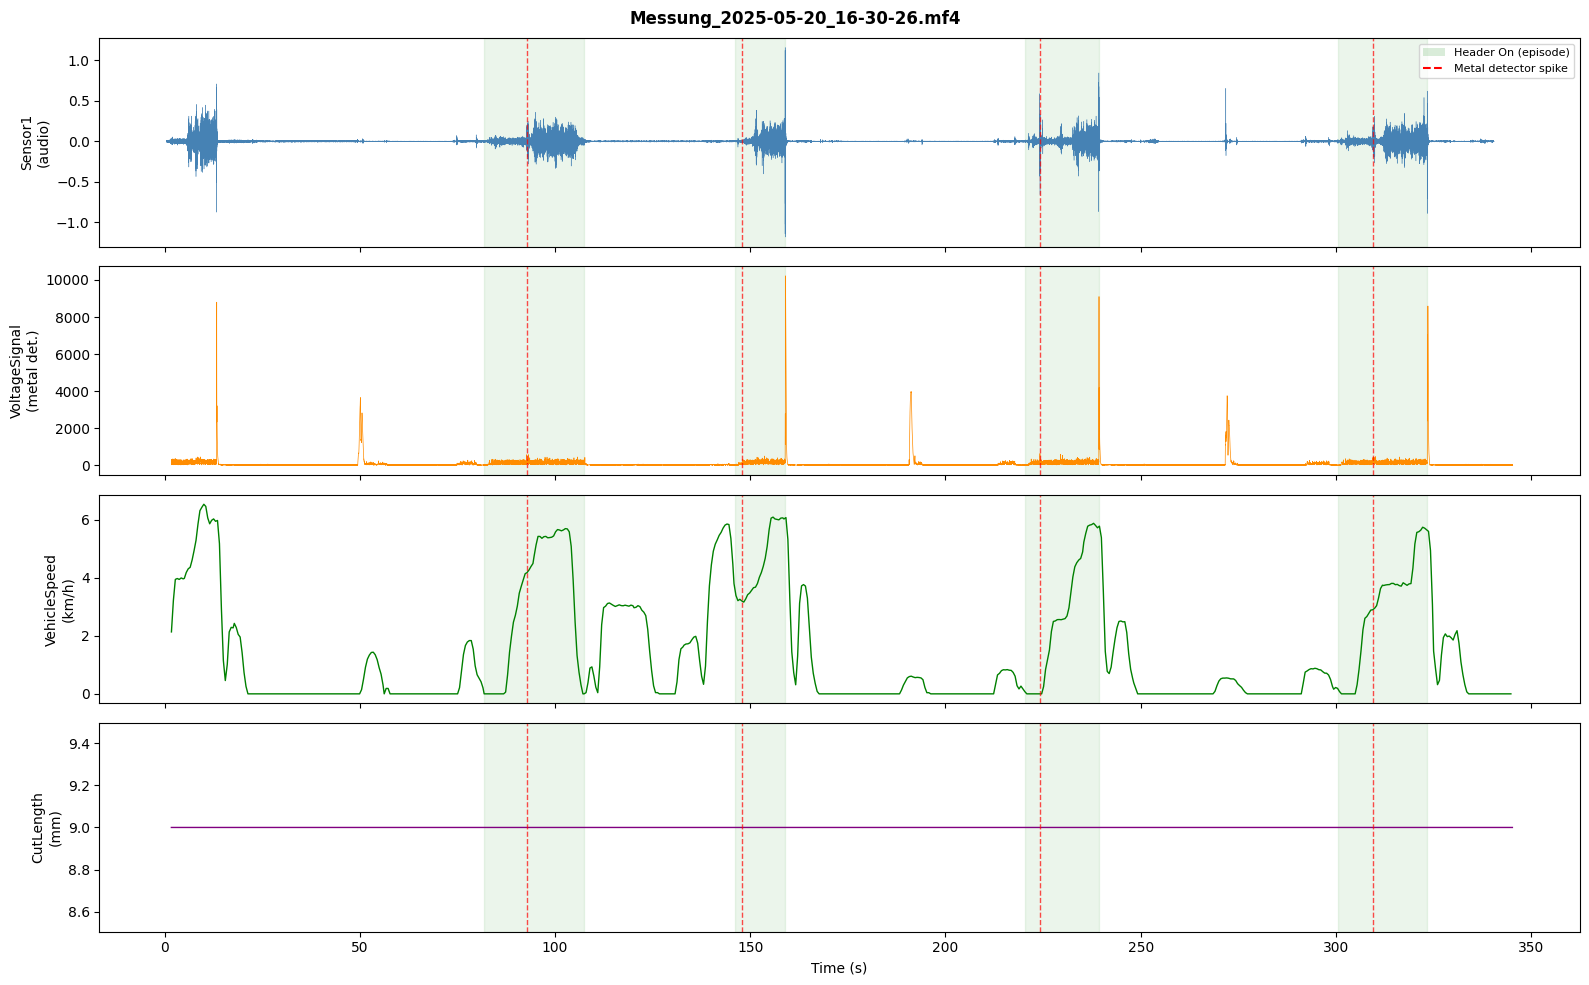

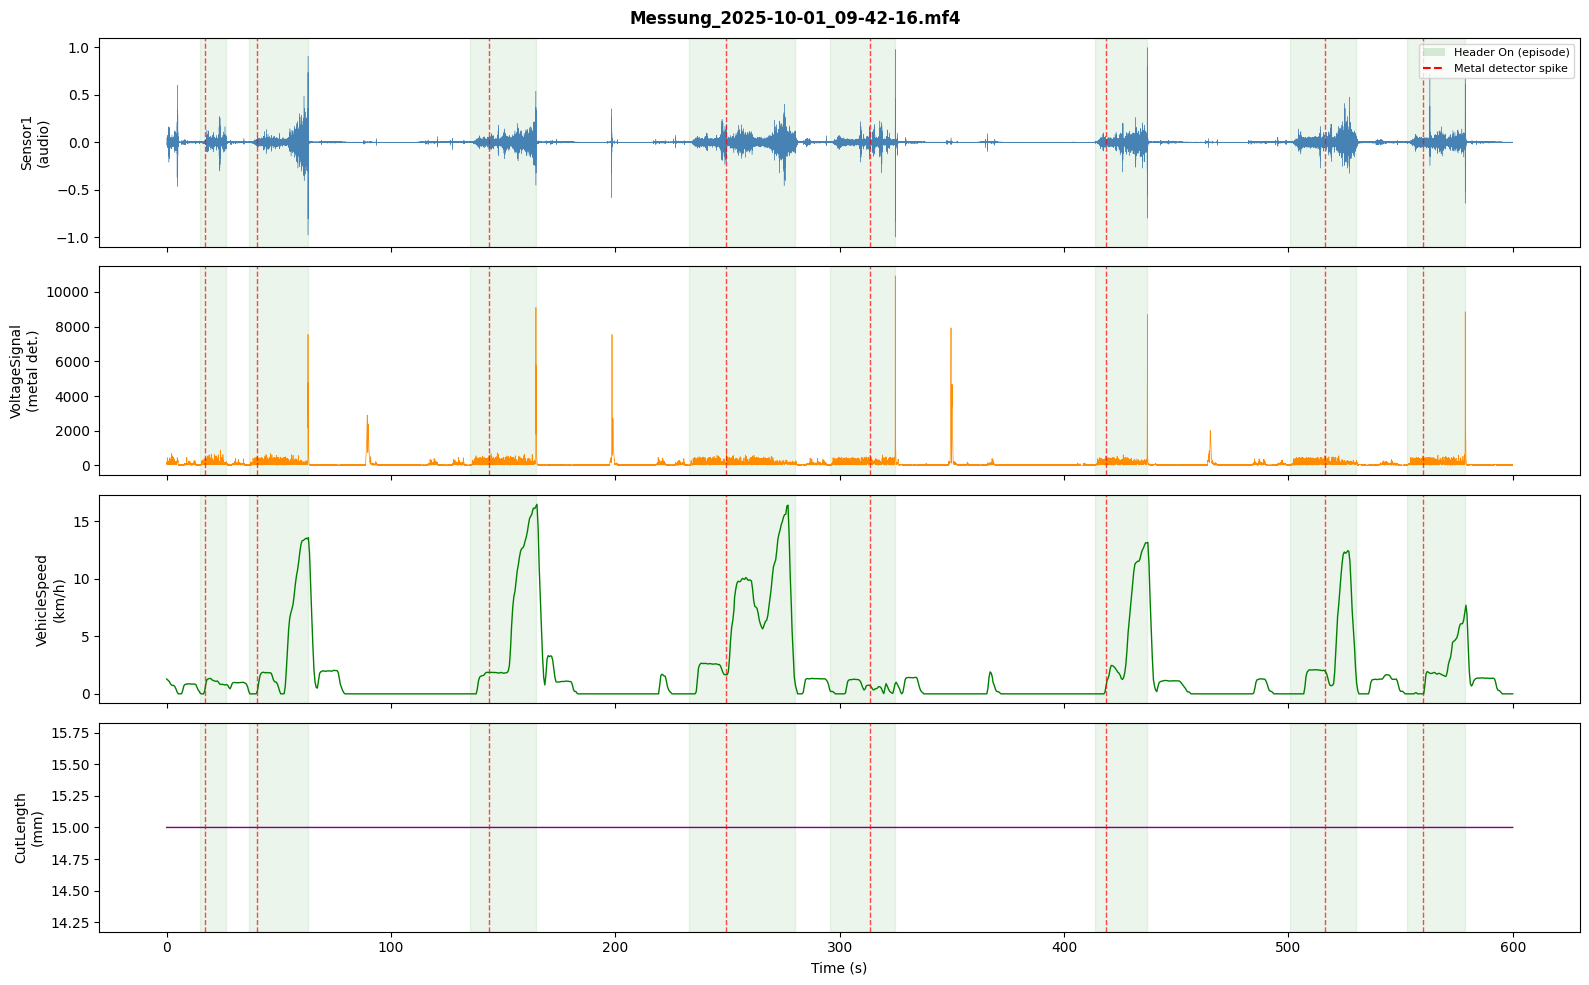

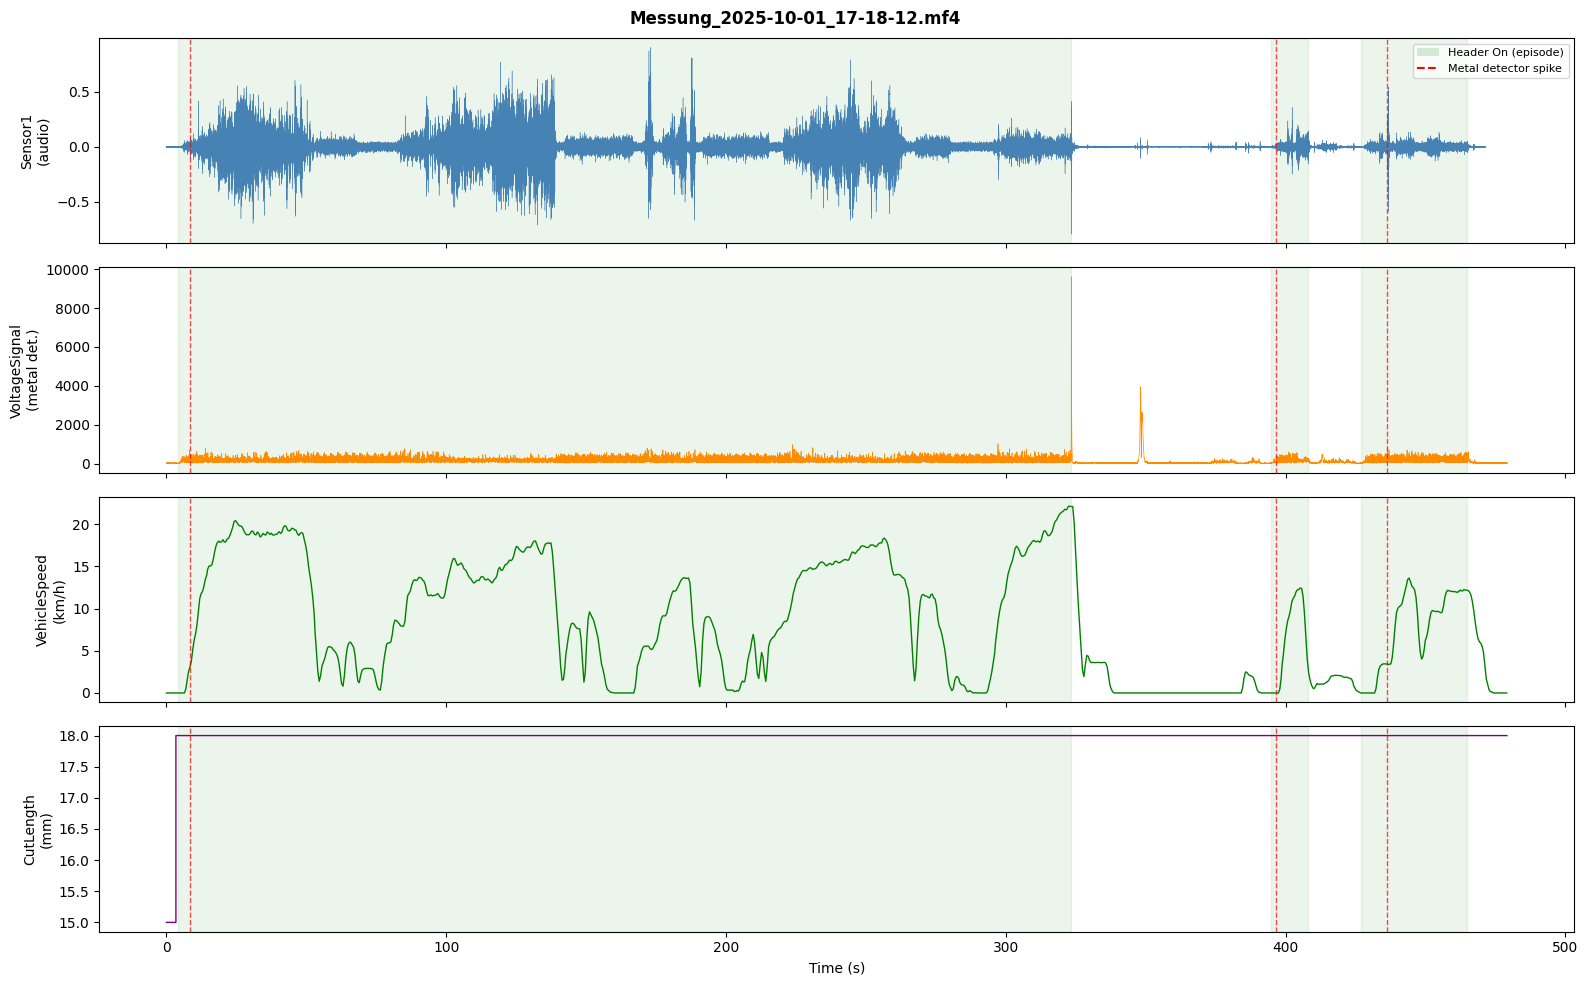

In [5]:
def plot_run_overview(f):
    ch = load_run(f)
    episodes = get_episodes(ch["Status"])
    stone_events = find_stone_events(ch["VoltageSignal"], episodes)
    
    fig, axes = plt.subplots(4, 1, figsize=(16, 10), sharex=True)
    fig.suptitle(f.name, fontsize=12, fontweight='bold')
    
    audio = ch["Sensor1"]
    volt = ch["VoltageSignal"]
    speed = ch["VehicleSpeed"]
    cut = ch["CutLength"]
    
    # Downsample audio for plotting (every 100th sample)
    step = 100
    axes[0].plot(audio.timestamps[::step], audio.samples[::step], lw=0.3, color='steelblue')
    axes[0].set_ylabel("Sensor1\n(audio)")
    
    axes[1].plot(volt.timestamps, volt.samples, lw=0.5, color='darkorange')
    axes[1].set_ylabel("VoltageSignal\n(metal det.)")
    
    axes[2].plot(speed.timestamps, speed.samples, lw=1.0, color='green')
    axes[2].set_ylabel("VehicleSpeed\n(km/h)")
    
    axes[3].step(cut.timestamps, cut.samples, lw=1.0, color='purple', where='post')
    axes[3].set_ylabel("CutLength\n(mm)")
    axes[3].set_xlabel("Time (s)")
    
    # Shade episode On-periods and mark stone events
    for ax in axes:
        for ep_start, ep_end in episodes:
            ax.axvspan(ep_start, ep_end, alpha=0.08, color='green', label='Header On')
        for spikes in stone_events:
            for spike_t in spikes[:1]:  # first spike only to avoid clutter
                ax.axvline(spike_t, color='red', lw=1.0, alpha=0.7, linestyle='--')
    
    # Legend once
    from matplotlib.patches import Patch
    from matplotlib.lines import Line2D
    axes[0].legend(handles=[
        Patch(facecolor='green', alpha=0.15, label='Header On (episode)'),
        Line2D([0],[0], color='red', linestyle='--', label='Metal detector spike'),
    ], loc='upper right', fontsize=8)
    
    plt.tight_layout()
    plt.show()

for f in MF4_FILES:
    plot_run_overview(f)

## 5. Zoom into a stone event — audio before vs after metal detector fires

This is the key view: we look at a ±2 second window around a metal detector spike to see whether
the audio signal shows anything distinctive *before* the spike.

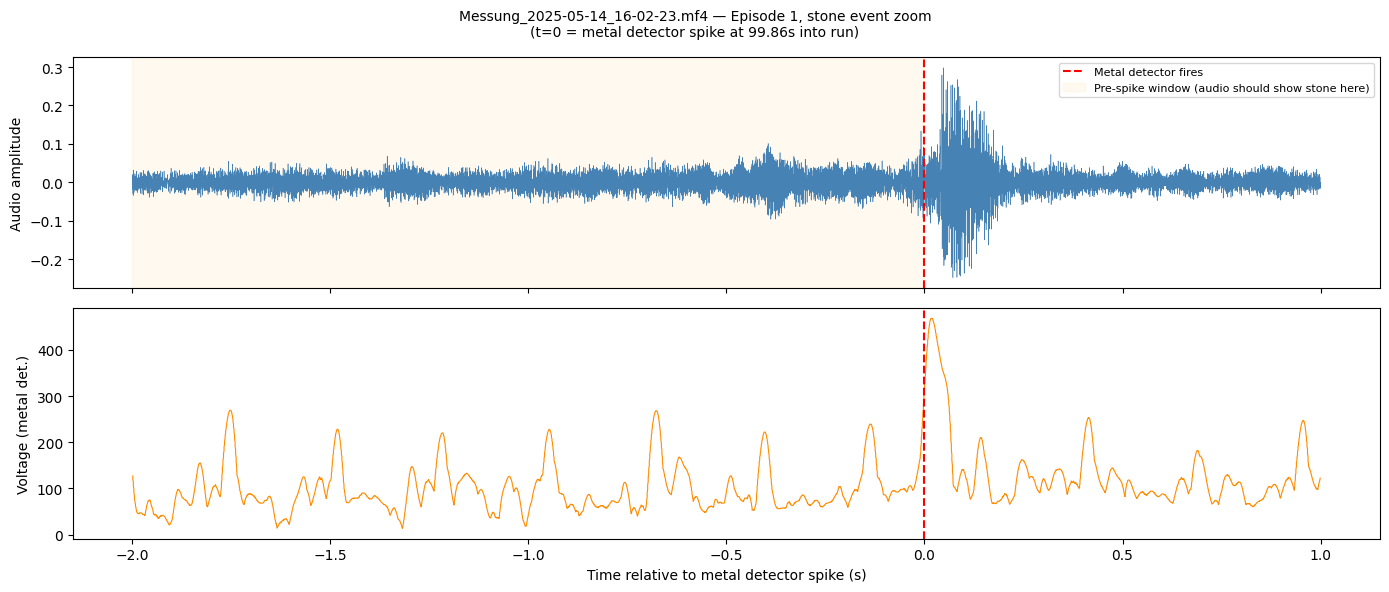

In [6]:
def plot_stone_event_zoom(f, episode_idx=0, window_before=2.0, window_after=1.0):
    ch = load_run(f)
    episodes = get_episodes(ch["Status"])
    stone_events = find_stone_events(ch["VoltageSignal"], episodes)
    
    if episode_idx >= len(episodes):
        print(f"No episode {episode_idx} in {f.name}")
        return
    
    spikes = stone_events[episode_idx]
    if not spikes:
        print(f"No stone event in episode {episode_idx} of {f.name}")
        return
    
    spike_t = spikes[0]
    t_lo = spike_t - window_before
    t_hi = spike_t + window_after
    
    audio = ch["Sensor1"]
    volt = ch["VoltageSignal"]
    
    # Slice audio
    a_mask = (audio.timestamps >= t_lo) & (audio.timestamps <= t_hi)
    a_t = audio.timestamps[a_mask] - spike_t  # relative to spike
    a_s = audio.samples[a_mask]
    
    # Slice voltage
    v_mask = (volt.timestamps >= t_lo) & (volt.timestamps <= t_hi)
    v_t = volt.timestamps[v_mask] - spike_t
    v_s = volt.samples[v_mask]
    
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 6), sharex=True)
    fig.suptitle(f"{f.name} — Episode {episode_idx+1}, stone event zoom\n"
                 f"(t=0 = metal detector spike at {spike_t:.2f}s into run)", fontsize=10)
    
    ax1.plot(a_t, a_s, lw=0.4, color='steelblue')
    ax1.axvline(0, color='red', lw=1.5, linestyle='--', label='Metal detector fires')
    ax1.axvspan(-window_before, 0, alpha=0.06, color='orange', label='Pre-spike window (audio should show stone here)')
    ax1.set_ylabel("Audio amplitude")
    ax1.legend(fontsize=8)
    
    ax2.plot(v_t, v_s, lw=0.8, color='darkorange')
    ax2.axvline(0, color='red', lw=1.5, linestyle='--')
    ax2.set_ylabel("Voltage (metal det.)")
    ax2.set_xlabel("Time relative to metal detector spike (s)")
    
    plt.tight_layout()
    plt.show()

# Run 2 has the clearest stone events (max voltage 10,668)
plot_stone_event_zoom(MF4_FILES[1], episode_idx=0)

## 6. Audio spectrogram around a stone event

A spectrogram shows which frequencies are present over time.  
If a stone impact makes a distinctive high-frequency burst, it will show up here as a vertical band *before* t=0.

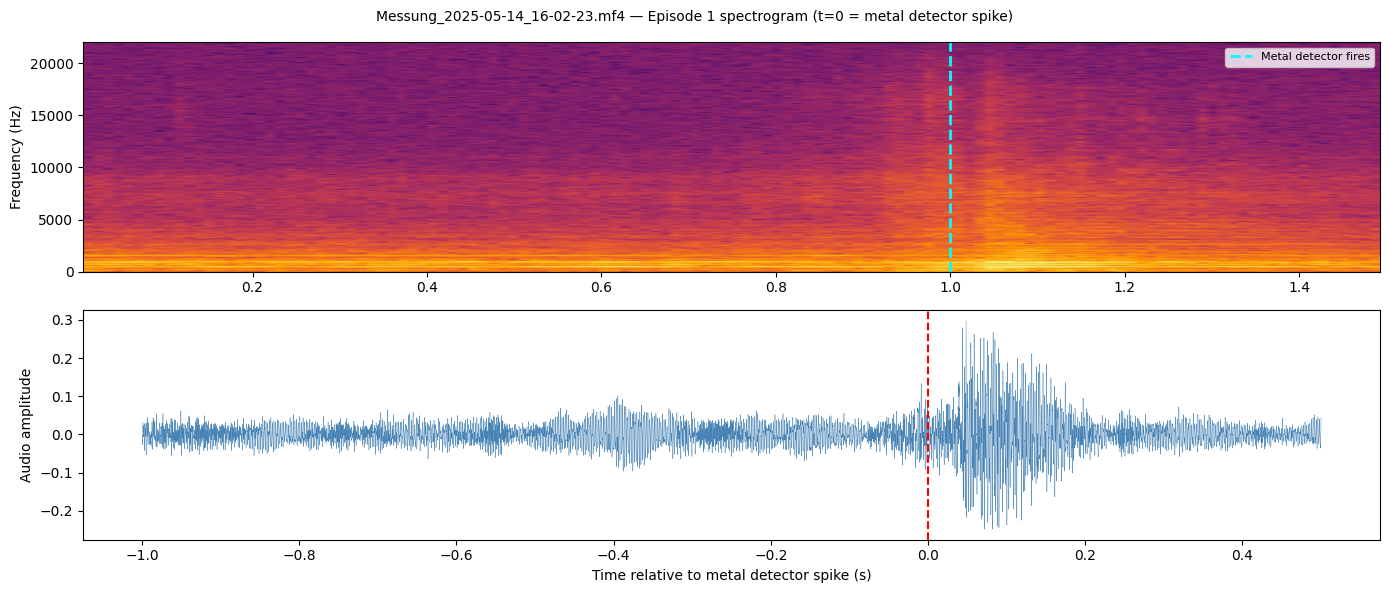

In [7]:
def plot_spectrogram_zoom(f, episode_idx=0, window_before=1.0, window_after=0.5):
    ch = load_run(f)
    episodes = get_episodes(ch["Status"])
    stone_events = find_stone_events(ch["VoltageSignal"], episodes)
    
    if episode_idx >= len(episodes):
        return
    spikes = stone_events[episode_idx]
    if not spikes:
        print(f"No stone event in episode {episode_idx} of {f.name}")
        return
    
    spike_t = spikes[0]
    audio = ch["Sensor1"]
    fs = len(audio.samples) / audio.timestamps[-1]  # ~44100 Hz
    
    a_mask = (audio.timestamps >= spike_t - window_before) & (audio.timestamps <= spike_t + window_after)
    a_s = audio.samples[a_mask]
    
    fig, axes = plt.subplots(2, 1, figsize=(14, 6))
    fig.suptitle(f"{f.name} — Episode {episode_idx+1} spectrogram (t=0 = metal detector spike)", fontsize=10)
    
    # Time axis label for spectrogram
    axes[0].specgram(a_s, Fs=fs, NFFT=1024, noverlap=512, cmap='inferno')
    axes[0].set_ylabel("Frequency (Hz)")
    axes[0].axvline(window_before, color='cyan', lw=2, linestyle='--', label='Metal detector fires')
    axes[0].legend(fontsize=8)
    
    axes[1].plot(np.linspace(-window_before, window_after, len(a_s)), a_s, lw=0.3, color='steelblue')
    axes[1].axvline(0, color='red', lw=1.5, linestyle='--')
    axes[1].set_ylabel("Audio amplitude")
    axes[1].set_xlabel("Time relative to metal detector spike (s)")
    
    plt.tight_layout()
    plt.show()

plot_spectrogram_zoom(MF4_FILES[1], episode_idx=0)

## 7. Compare: audio during normal harvesting vs stone episode

To train a model, we need to know what "normal" audio looks like.  
Here we compare RMS energy (loudness over time) between a no-stone episode and a stone episode.

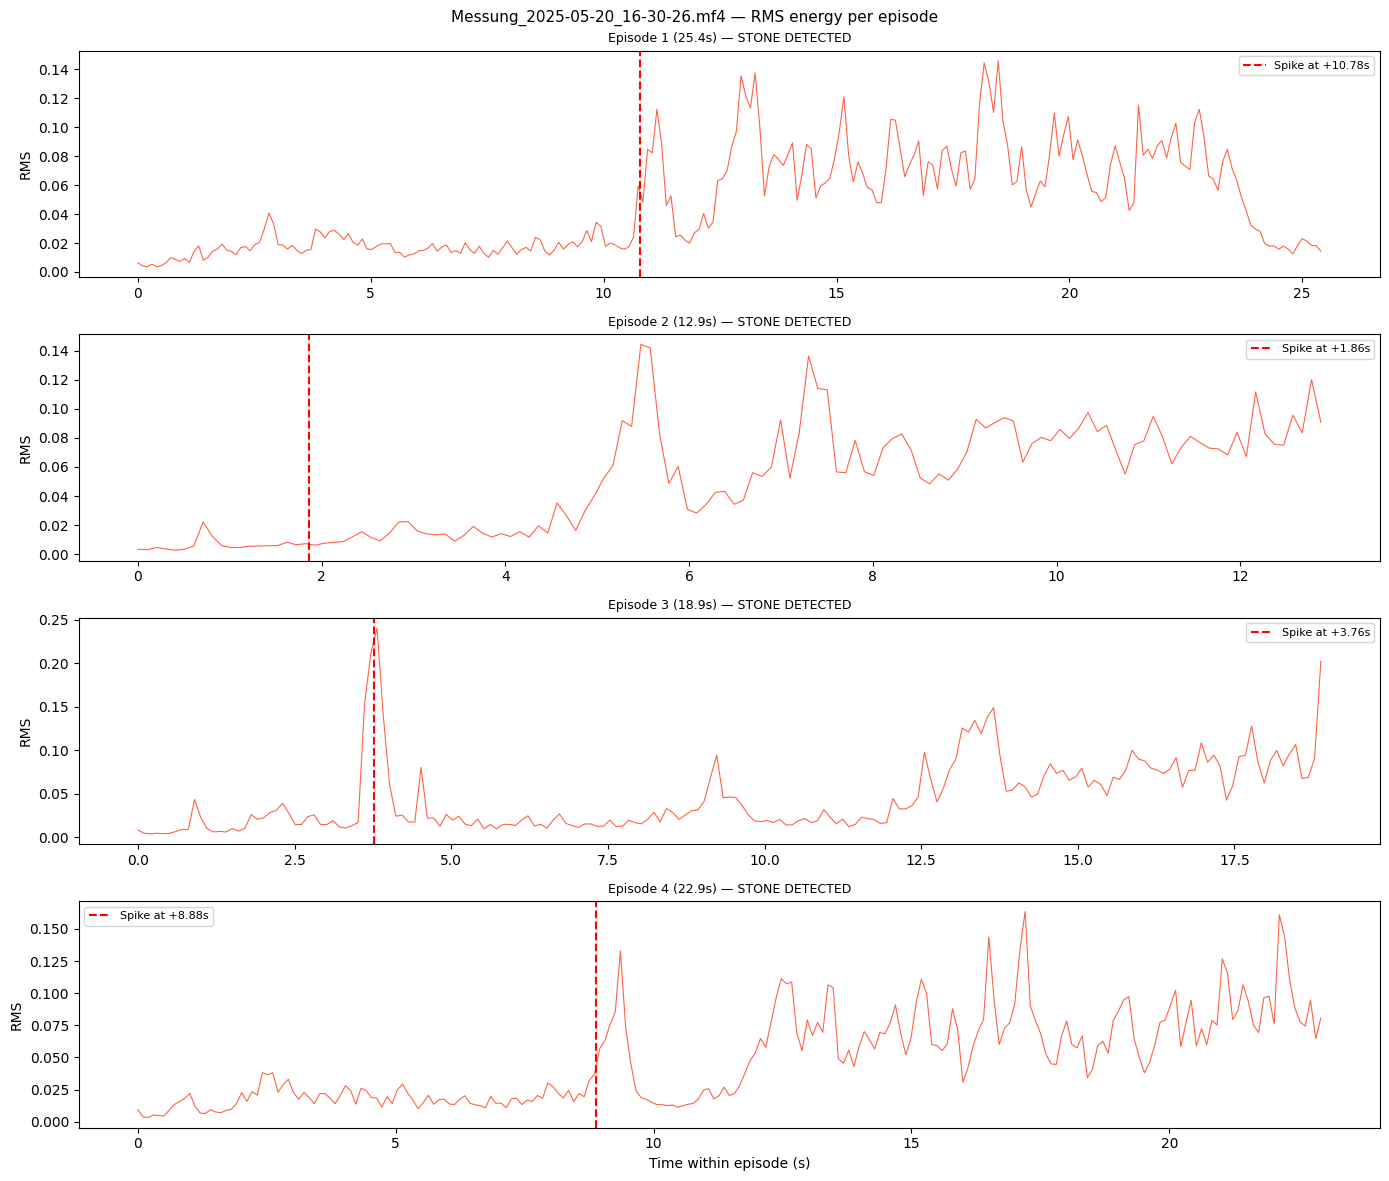

In [8]:
def rms_envelope(signal, window_samples=4410):
    """Compute RMS energy in non-overlapping windows (~100ms at 44.1kHz)."""
    n = len(signal) // window_samples
    rms = np.array([
        np.sqrt(np.mean(signal[i*window_samples:(i+1)*window_samples]**2))
        for i in range(n)
    ])
    return rms

# Run 3 has 4 episodes — good candidate for comparing stone vs no-stone within the same run
f = MF4_FILES[2]  # 2025-05-20 — 4 episodes
ch = load_run(f)
episodes = get_episodes(ch["Status"])
stone_events = find_stone_events(ch["VoltageSignal"], episodes)
audio = ch["Sensor1"]
fs = len(audio.samples) / audio.timestamps[-1]
window_s = 0.1  # 100ms RMS windows
window_samples = int(fs * window_s)

fig, axes = plt.subplots(len(episodes), 1, figsize=(14, 3 * len(episodes)), sharex=False)
fig.suptitle(f"{f.name} — RMS energy per episode", fontsize=11)

for i, (ep, spikes) in enumerate(zip(episodes, stone_events)):
    ep_mask = (audio.timestamps >= ep[0]) & (audio.timestamps <= ep[1])
    ep_audio = audio.samples[ep_mask]
    rms = rms_envelope(ep_audio, window_samples)
    t_rms = np.linspace(0, ep[1] - ep[0], len(rms))
    
    label = f"Episode {i+1} ({ep[1]-ep[0]:.1f}s)"
    color = 'tomato' if spikes else 'steelblue'
    axes[i].plot(t_rms, rms, color=color, lw=0.8)
    axes[i].set_ylabel("RMS")
    axes[i].set_title(label + (" — STONE DETECTED" if spikes else " — no stone"), fontsize=9)
    
    if spikes:
        spike_rel = spikes[0] - ep[0]
        axes[i].axvline(spike_rel, color='red', lw=1.5, linestyle='--', label=f'Spike at +{spike_rel:.2f}s')
        axes[i].legend(fontsize=8)

axes[-1].set_xlabel("Time within episode (s)")
plt.tight_layout()
plt.show()

## 8. Dataset summary for modeling

Before building a model, it's useful to know the total labeled data available.

In [9]:
print("Dataset summary for modeling")
print("=" * 60)
total_stone = 0
total_no_stone = 0
total_stone_dur = 0
total_no_stone_dur = 0

for f in MF4_FILES:
    ch = load_run(f)
    episodes = get_episodes(ch["Status"])
    stone_events = find_stone_events(ch["VoltageSignal"], episodes)
    
    print(f"\n{f.name}")
    for i, (ep, spikes) in enumerate(zip(episodes, stone_events)):
        dur = ep[1] - ep[0]
        has_stone = bool(spikes)
        print(f"  Ep {i+1}: {dur:.1f}s  {'STONE' if has_stone else 'clean'}")
        if has_stone:
            total_stone += 1
            total_stone_dur += dur
        else:
            total_no_stone += 1
            total_no_stone_dur += dur

print(f"\n{'='*60}")
print(f"Total episodes with stone:    {total_stone}  ({total_stone_dur:.1f}s)")
print(f"Total episodes without stone: {total_no_stone}  ({total_no_stone_dur:.1f}s)")
print(f"Total episodes:               {total_stone + total_no_stone}")
print(f"\nNote: 'clean' episodes where VoltageSignal never spiked may include")
print(f"non-metallic stones (undetectable by metal detector — unknown ground truth).")

Dataset summary for modeling

Messung_2025-05-09_08-59-34.mf4
  Ep 1: 71.9s  STONE
  Ep 2: 57.6s  STONE

Messung_2025-05-14_16-02-23.mf4
  Ep 1: 27.1s  STONE

Messung_2025-05-20_16-30-26.mf4
  Ep 1: 25.4s  STONE
  Ep 2: 12.9s  STONE
  Ep 3: 18.9s  STONE
  Ep 4: 22.9s  STONE

Messung_2025-10-01_09-42-16.mf4
  Ep 1: 11.8s  STONE
  Ep 2: 26.2s  STONE
  Ep 3: 29.3s  STONE
  Ep 4: 47.4s  STONE
  Ep 5: 29.0s  STONE
  Ep 6: 23.4s  STONE
  Ep 7: 29.4s  STONE
  Ep 8: 26.0s  STONE

Messung_2025-10-01_17-18-12.mf4
  Ep 1: 319.2s  STONE
  Ep 2: 13.2s  STONE
  Ep 3: 37.9s  STONE

Total episodes with stone:    18  (829.6s)
Total episodes without stone: 0  (0.0s)
Total episodes:               18

Note: 'clean' episodes where VoltageSignal never spiked may include
non-metallic stones (undetectable by metal detector — unknown ground truth).
